In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
log_files = {
    "Baseline": "training_baseline_7M.json",
    "Expert Shaping": "training_expert_shaping_7M.json",
    "Expert Shaping + Death Penalty": "training_expert_shaping__death_penalty_7M.json",
}

logs = {}
for name, path in log_files.items():
    try:
        with open(path) as f:
            logs[name] = json.load(f)
        print(f"Loaded {name}: {len(logs[name]['episode_rewards'])} episodes")
    except FileNotFoundError:
        print(f"File not found: {path}")

Loaded Baseline: 134640 episodes
Loaded Expert Shaping: 157538 episodes
Loaded Expert Shaping + Death Penalty: 132511 episodes


In [3]:
for name, log in logs.items():
    rewards = np.array(log["episode_rewards"])
    near_zero = np.where(rewards < 50)[0]
    
    # Find runs of consecutive near-zero episodes
    if len(near_zero) > 0:
        gaps = np.diff(near_zero)
        run_starts = near_zero[np.where(np.concatenate([[1], gaps > 1]))[0]]
        run_lengths = []
        current_len = 1
        for g in gaps:
            if g == 1:
                current_len += 1
            else:
                run_lengths.append(current_len)
                current_len = 1
        run_lengths.append(current_len)
        
        long_crashes = [(s, l) for s, l in zip(run_starts, run_lengths) if l > 100]
        print(f"\n{name}")
        print(f"  Total near-zero episodes (<50): {len(near_zero)}")
        print(f"  Sustained crashes (>100 consecutive near-zero eps):")
        for start, length in long_crashes:
            print(f"    Episode {start:,} to {start+length:,} ({length} episodes)")
    else:
        print(f"\n{name}: no near-zero episodes found")


Baseline
  Total near-zero episodes (<50): 36441
  Sustained crashes (>100 consecutive near-zero eps):

Expert Shaping
  Total near-zero episodes (<50): 63832
  Sustained crashes (>100 consecutive near-zero eps):

Expert Shaping + Death Penalty
  Total near-zero episodes (<50): 35381
  Sustained crashes (>100 consecutive near-zero eps):


In [4]:
for name, log in logs.items():
    rewards = np.array(log["episode_rewards"])
    lengths = np.array(log["episode_lengths"])
    
    # Pearson correlation between reward and length
    corr = np.corrcoef(rewards, lengths)[0, 1]
    
    # Mean length during crash vs normal play
    crash_mask = rewards < 50
    normal_mask = rewards >= 50
    
    mean_len_crash  = np.mean(lengths[crash_mask])  if crash_mask.sum()  > 0 else None
    mean_len_normal = np.mean(lengths[normal_mask]) if normal_mask.sum() > 0 else None
    
    print(f"\n{name}")
    print(f"  Reward-length correlation: {corr:.3f}")
    print(f"  Mean episode length during crash (<50 reward): {mean_len_crash:.1f}" 
          if mean_len_crash else "  No crash episodes")
    print(f"  Mean episode length during normal play: {mean_len_normal:.1f}"
          if mean_len_normal else "  No normal episodes")


Baseline
  Reward-length correlation: 0.762
  Mean episode length during crash (<50 reward): 31.4
  Mean episode length during normal play: 59.6

Expert Shaping
  Reward-length correlation: 0.702
  Mean episode length during crash (<50 reward): 27.7
  Mean episode length during normal play: 55.8

Expert Shaping + Death Penalty
  Reward-length correlation: 0.713
  Mean episode length during crash (<50 reward): 32.4
  Mean episode length during normal play: 60.3


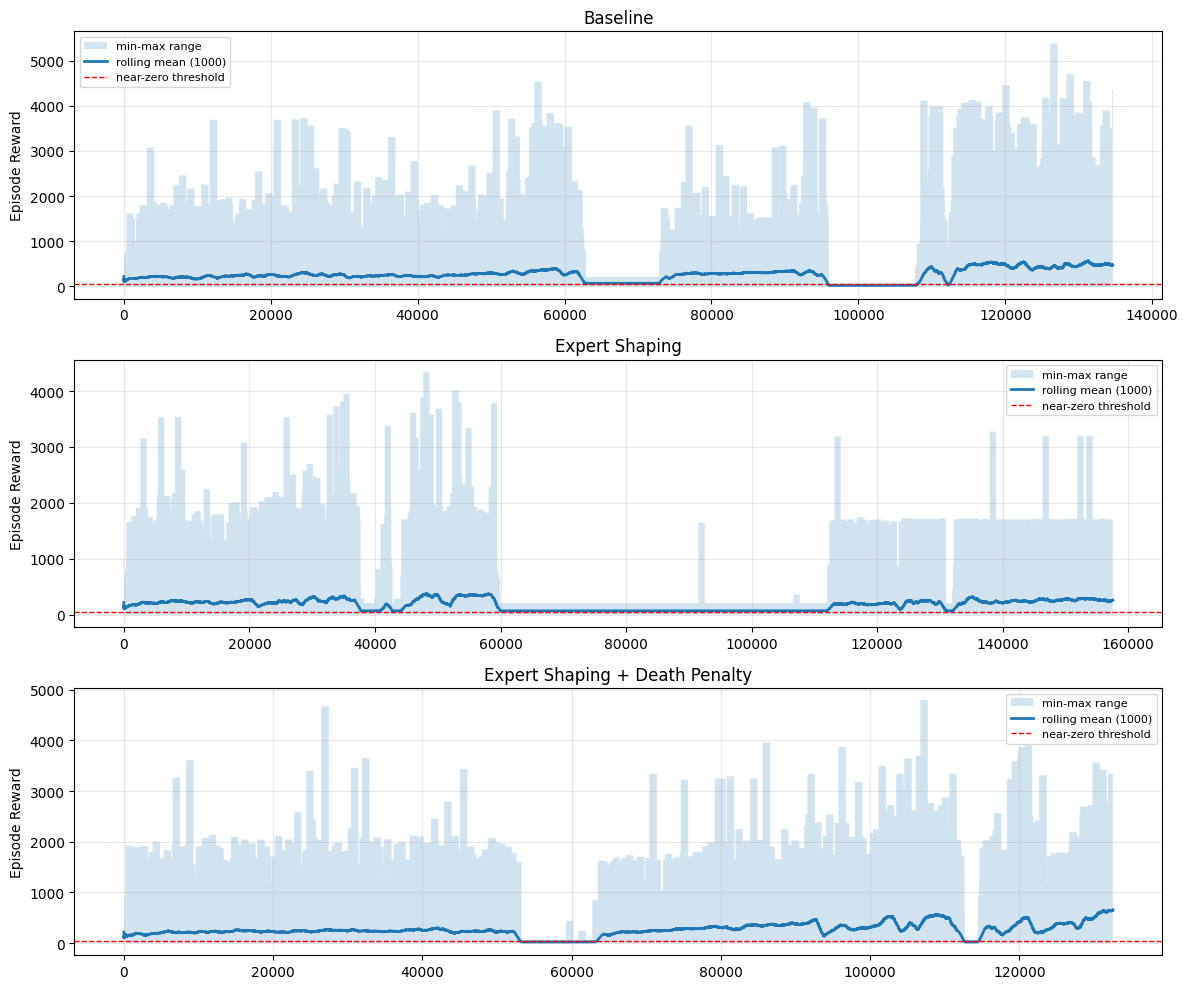

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=False)

for ax, (name, log) in zip(axes, logs.items()):
    rewards = pd.Series(log["episode_rewards"])
    rolling_mean = rewards.rolling(1000, min_periods=1).mean()
    rolling_min  = rewards.rolling(1000, min_periods=1).min()
    rolling_max  = rewards.rolling(1000, min_periods=1).max()
    
    ax.fill_between(range(len(rewards)), rolling_min, rolling_max, 
                    alpha=0.2, label="min-max range")
    ax.plot(rolling_mean.values, linewidth=2, label="rolling mean (1000)")
    ax.axhline(50, color="red", linestyle="--", linewidth=1, label="near-zero threshold")
    ax.set_title(name)
    ax.set_ylabel("Episode Reward")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("crash_verification.png", dpi=130)
plt.show()

In [6]:
# Compare shaped vs true reward gap during crash vs normal periods
for name, log in logs.items():
    true_r   = np.array(log["episode_rewards"])
    shaped_r = np.array(log["episode_shaped_rewards"])
    
    crash_mask  = true_r < 50
    normal_mask = true_r >= 50
    
    # Gap between shaped and true reward
    gap = shaped_r - true_r
    
    print(f"\n{name}")
    print(f"  Mean shaped-true gap during normal play: {np.mean(gap[normal_mask]):.2f}")
    print(f"  Mean shaped-true gap during crash:       {np.mean(gap[crash_mask]):.2f}")
    print(f"  Std of shaped reward during normal play: {np.std(shaped_r[normal_mask]):.2f}")
    print(f"  Std of shaped reward during crash:       {np.std(shaped_r[crash_mask]):.2f}")
    print(f"  Std of true reward during normal play:   {np.std(true_r[normal_mask]):.2f}")
    print(f"  Std of true reward during crash:         {np.std(true_r[crash_mask]):.2f}")


Baseline
  Mean shaped-true gap during normal play: 0.00
  Mean shaped-true gap during crash:       0.00
  Std of shaped reward during normal play: 370.65
  Std of shaped reward during crash:       14.63
  Std of true reward during normal play:   370.65
  Std of true reward during crash:         14.63

Expert Shaping
  Mean shaped-true gap during normal play: 0.00
  Mean shaped-true gap during crash:       0.00
  Std of shaped reward during normal play: 266.51
  Std of shaped reward during crash:       10.77
  Std of true reward during normal play:   266.51
  Std of true reward during crash:         10.77

Expert Shaping + Death Penalty
  Mean shaped-true gap during normal play: 0.00
  Mean shaped-true gap during crash:       0.00
  Std of shaped reward during normal play: 347.72
  Std of shaped reward during crash:       17.66
  Std of true reward during normal play:   347.72
  Std of true reward during crash:         17.66


In [7]:
# Check how many unique update cycles occurred
# n_updates = total_timesteps / n_steps
for name, log in logs.items():
    total_eps   = len(log["episode_rewards"])
    total_steps = sum(log["episode_lengths"])
    n_updates   = total_steps // 128
    print(f"\n{name}")
    print(f"  Total steps:   {total_steps:,}")
    print(f"  Total episodes:{total_eps:,}")
    print(f"  PPO updates:   {n_updates:,}")
    print(f"  Steps/episode: {total_steps/total_eps:.1f}")


Baseline
  Total steps:   7,000,020
  Total episodes:134,640
  PPO updates:   54,687
  Steps/episode: 52.0

Expert Shaping
  Total steps:   7,000,061
  Total episodes:157,538
  PPO updates:   54,687
  Steps/episode: 44.4

Expert Shaping + Death Penalty
  Total steps:   7,000,042
  Total episodes:132,511
  PPO updates:   54,687
  Steps/episode: 52.8


In [9]:
def plot_learning_curves_multiseed(results_ms, CONDITIONS, total_steps):
    fig, ax = plt.subplots(figsize=(11, 5))

    for name, seed_runs in results_ms.items():
        valid = [r for r in seed_runs if r is not None]
        if not valid:
            continue
        color = CONDITIONS[name]["color"]

        all_smoothed = []
        for run in valid:
            rewards = run["episode_rewards"]
            window = max(1, int(len(rewards) * 0.01))
            s = pd.Series(rewards).rolling(window, min_periods=1).mean().values
            ax.plot(s, color=color, linewidth=1, alpha=0.2)
            all_smoothed.append(s)

        min_len    = min(len(s) for s in all_smoothed)
        mean_curve = np.array([s[:min_len] for s in all_smoothed]).mean(axis=0)
        # Window label uses the mean episode count across seeds
        mean_eps   = int(np.mean([len(r["episode_rewards"]) for r in valid]))
        window_label = max(1, int(mean_eps * 0.01))
        ax.plot(mean_curve, color=color, linewidth=2.5, label=name)

    ax.set_xlabel("Episode")
    ax.set_ylabel(f"True Game Score (rolling mean, window ≈ 1% of episodes)")
    ax.set_title(
        f"Learning Curves: {total_steps:,} steps | "
        f"{len(SEED_SHORT)} seeds (faint lines) + mean (solid)"
    )
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(f"plot_learning_curves_{total_steps // 1_000_000}M_multiseed.png", dpi=130)
    plt.show()


def plot_learning_curves_single(res_dict, CONDITIONS, total_steps, suffix=""):
    fig, ax = plt.subplots(figsize=(11, 5))
    for name, data in res_dict.items():
        if data is None:
            continue
        rewards = data["episode_rewards"]
        window  = max(1, int(len(rewards) * 0.01))
        s = pd.Series(rewards).rolling(window, min_periods=1).mean()
        ax.plot(s, color=CONDITIONS[name]["color"], linewidth=2, label=name)

    ax.set_xlabel("Episode")
    ax.set_ylabel("True Game Score (rolling mean, window ≈ 1% of episodes)")
    ax.set_title(f"Learning Curves: {total_steps:,} steps{suffix}")
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(f"plot_learning_curves_{total_steps // 1_000_000}M.png", dpi=130)
    plt.show()

plot_learning_curves_single(results_mid,  CONDITIONS, TOTAL_STEPS_MID)
plot_learning_curves_single(results_long, CONDITIONS, TOTAL_STEPS_LONG)

NameError: name 'results_mid' is not defined